In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import random

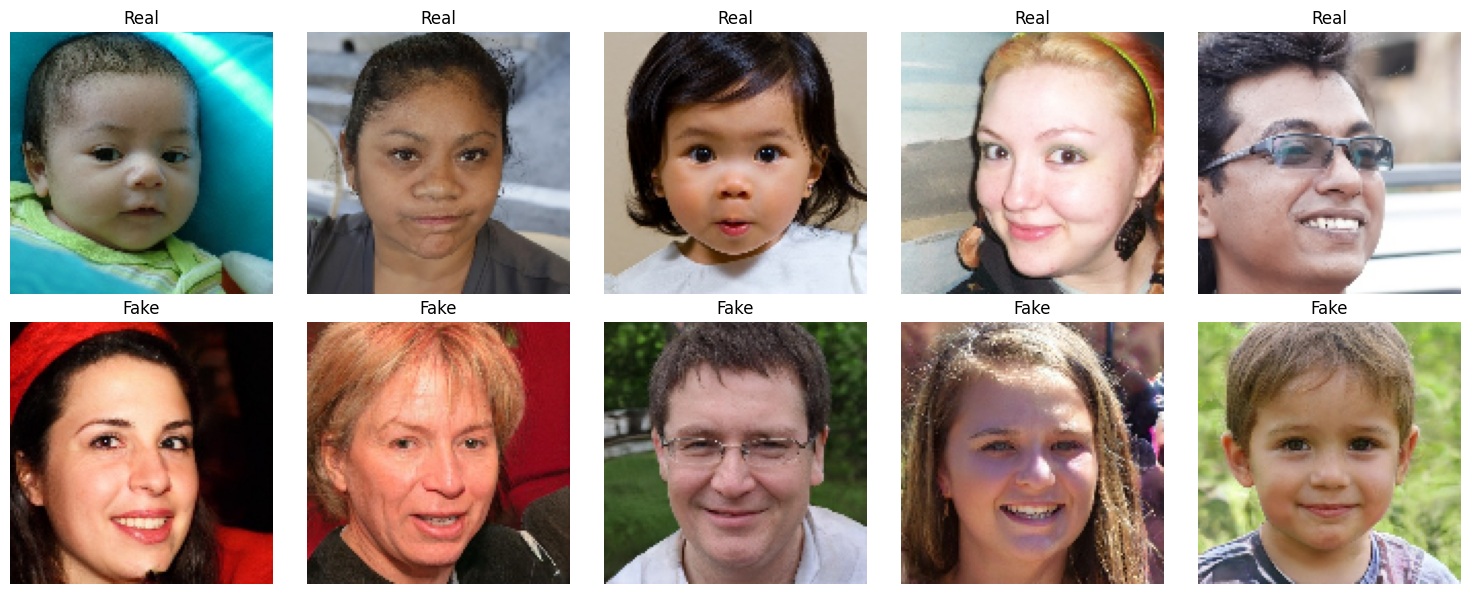

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Classes : {'fake': 0, 'real': 1}


c:\Users\souma\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\souma\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1615s 258ms/step - accuracy: 0.6977 - loss: 0.5739 - val_accuracy: 0.8382 - val_loss: 0.3734
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 495s 79ms/step - accuracy: 0.8466 - loss: 0.3546 - val_accuracy: 0.8808 - val_loss: 0.2825
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 497s 80ms/step - accuracy: 0.8956 - loss: 0.2515 - val_accuracy: 0.9072 - val_loss: 0.2269
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 499s 80ms/step - accuracy: 0.9209 - loss: 0.1985 - val_accuracy: 0.9137 - val_loss: 0.2180
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 510s 82ms/step - accuracy: 0.9353 - loss: 0.1640 - val_accuracy: 0.9177 - val_loss: 0.2135
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 560s 90ms/step - accuracy: 0.9452 - loss: 0.1384 - val_accuracy: 0.9262 - val_loss: 0.1969
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 572s 91ms/step - accuracy: 0.9522 - loss: 0.1223 - val_accuracy: 0.9316 - val_loss: 0.1964
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 574s 92ms/step - accuracy

In [ ]:
# Paths of the directories
train_dir = r"C:\Users\sf\Desktop\real-vs-fake\train"
val_dir = r"C:\Users\sf\Desktop\real-vs-fake\valid"
test_dir = r"C:\Users\sf\Desktop\real-vs-fake\test"


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.preprocessing.image import load_img
import os

# Displaying some images
def plot_sample_images(base_dir, num_samples=5):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    for i, folder_name in enumerate(['real', 'fake']):
        folder_path = os.path.join(base_dir, folder_name)
        sample_images = os.listdir(folder_path)[:num_samples]
        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(folder_path, img_name)
            img = load_img(img_path, target_size=(128, 128))
            axes[i, j].imshow(img)
            axes[i, j].set_title(folder_name.capitalize())
            axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_images(train_dir)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Normalization of the images
datagen = ImageDataGenerator(rescale=1.0/255.0)
# Size of images and batch size
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16

# Generator for training data
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  
    shuffle=True  
)

# Generator for validation data
val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  
)

# Generator for test data
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  
)
print("Classes :", train_generator.class_indices)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  
])

# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

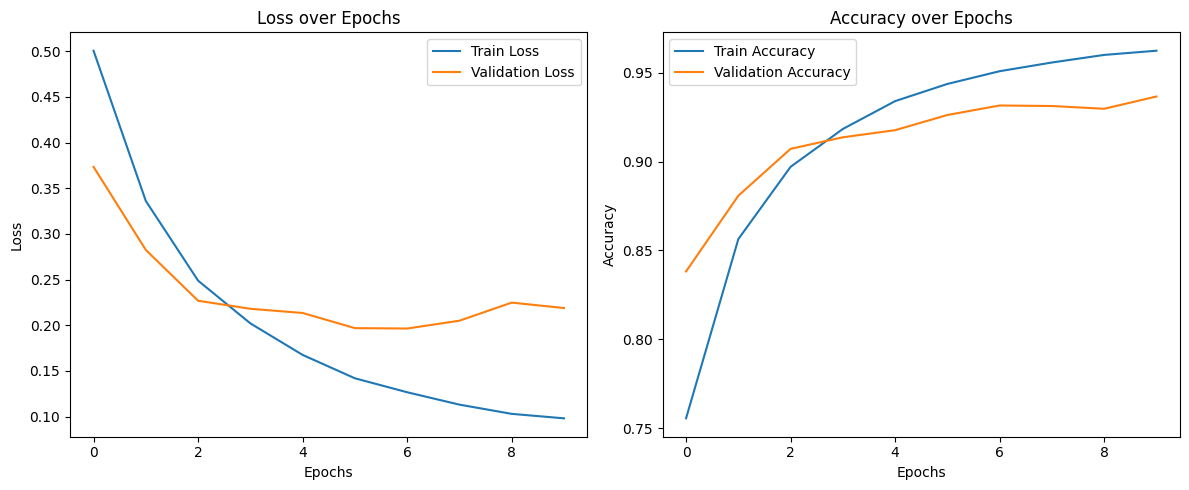

In [11]:
plt.figure(figsize=(12, 5))

# Perte (loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Précision (accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)


print("Classes prédites :", predicted_classes)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 242s 194ms/step
Classes prédites : [0 0 0 ... 1 1 1]


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step


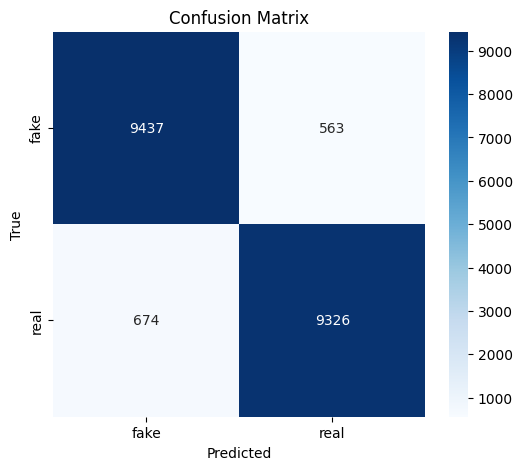

              precision    recall  f1-score   support

        fake       0.93      0.94      0.94     10000
        real       0.94      0.93      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Predict the class probabilities
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Step 2: Get the true labels
y_true = test_generator.classes

# Step 3: Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Step 4: Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Optional: classification report
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))


In [15]:
from sklearn.metrics import classification_report

# rapport
report = classification_report(y_true, y_pred_classes, target_names=['Fake', 'Real'])
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        Fake       0.93      0.94      0.94     10000
        Real       0.94      0.93      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



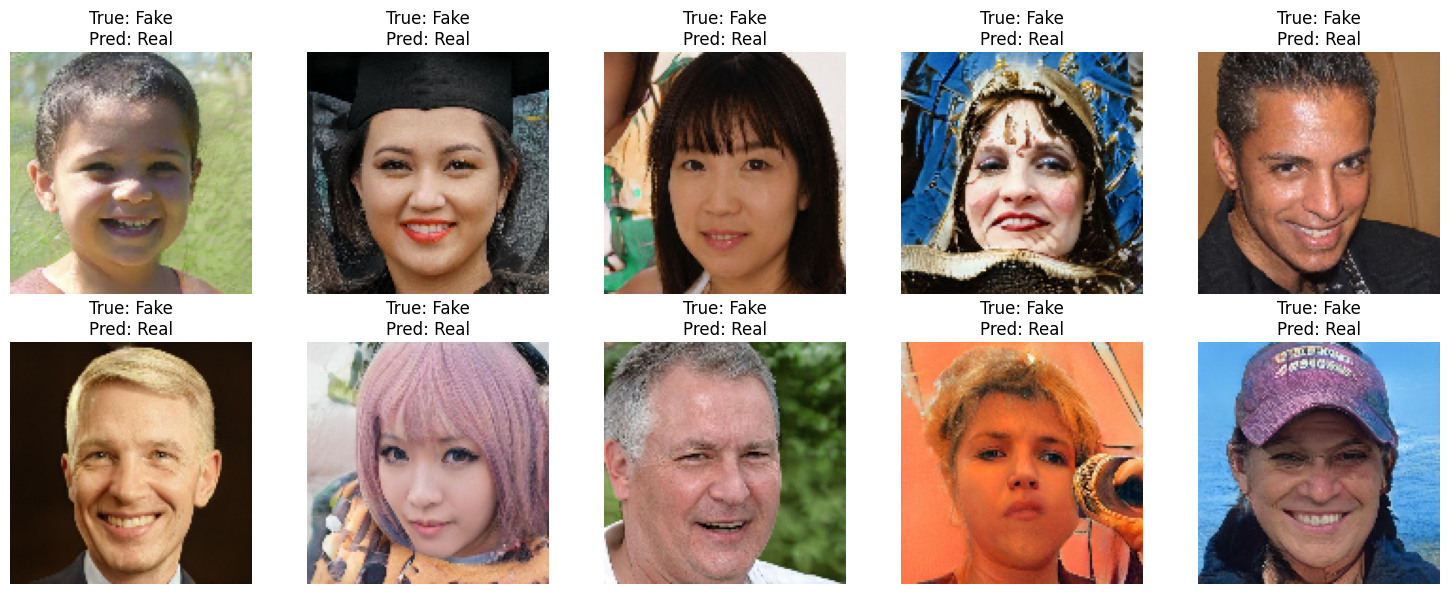

In [16]:
# False predictions
incorrect_indices = np.where(y_pred_classes != y_true)[0]

# displaying some samples of errors
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, idx in enumerate(incorrect_indices[:10]):
    img_path = test_generator.filepaths[idx]
    img = load_img(img_path, target_size=(128, 128))
    true_label = 'Real' if y_true[idx] == 1 else 'Fake'
    pred_label = 'Real' if y_pred_classes[idx] == 1 else 'Fake'

    ax = axes[i // 5, i % 5]
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [18]:
model.save('model.h5')